In [62]:
import numpy as np
import matplotlib.pyplot as plt

In [63]:
data = [
    [12.0, 1.5, 1, 'Wine'],
    [5.0, 2.0, 0, 'Beer'],
    [40.0, 0.0, 1, 'Whiskey'],
    [13.5, 1.2, 1, 'Wine'],
    [4.5, 1.8, 0, 'Beer'],
    [38.0, 0.1, 1, 'Whiskey'],
    [11.5, 1.7, 1, 'Wine'],
    [5.5, 2.3, 0, 'Beer']
]

Feature_map={
    0:"Alcohol Content (%)",
    1:"Sugar (g/L)",
    2:"Color (0: light, 1: dark)",
    3:"Drink Type"
}

encode={"Wine":0,"Beer":1,"Whiskey":2}
decode={0:"Wine",1:"Beer",2:"Whiskey"}
#label encoding the target variable. One hot encoding is not very helpful for decision trees.

np.random.seed(420)
data.sort(key=lambda x: np.random.random())

X=np.array([row[0:3] for row in data])
Y=np.array([encode[row[3]] for row in data])

X_train, Y_train = X[:6], Y[:6]
X_val, Y_val = X[6:], Y[6:]

mean_train = X_train.mean(axis=0)
std_train = X_train.std(axis=0)
#X_train = (X_train - mean_train) / std_train
#X_val = (X_val - mean_train) / std_train
#similarly, normalization is useless for decision trees.

In [64]:
def GiniImpurity(Y):
    if len(Y)==0:
        return 0
    count=np.bincount(Y)
    prob=count/len(Y)
    return 1-np.sum(prob**2)

def Entropy(Y):
    if len(Y)==0:
        return 0
    count=np.bincount(Y)
    prob=count/len(Y)
    return -np.sum(prob*np.log(prob+1e-10))

def InformationGain(Y,Y_left,Y_right,criterion=GiniImpurity):
    return criterion(Y)-len(Y_left)/len(Y)*criterion(Y_left)-len(Y_right)/len(Y)*criterion(Y_right)

#Gini impurity and entropy functions, and the information gain function that uses them to calculate the gain from a split. 

In [65]:
def BestSplit(X,Y,criterion=GiniImpurity):
    best_gain=-1
    best_feature=None
    best_threshold=None
    for feature in range(X.shape[1]):
        # Use midpoints between sorted unique values as well as the unique values themselves for better threshold selection
        sorted_values = np.sort(np.unique(X[:,feature]))
        thresholds =np.append(sorted_values,(sorted_values[:-1] + sorted_values[1:]) / 2)
        #thresholds=( sorted_values[:-1] + sorted_values[1:] )/ 2
        if len(thresholds) == 0:
            continue
        for threshold in thresholds:
            left_indices=X[:,feature]<=threshold
            right_indices=X[:,feature]>threshold
            if len(Y[left_indices])==0 or len(Y[right_indices])==0:
                continue
            gain=InformationGain(Y,Y[left_indices],Y[right_indices],criterion)
            if gain>best_gain:
                best_gain=gain
                best_feature=feature
                best_threshold=threshold
    return best_feature, best_threshold

In [66]:
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature_index = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

    def is_leaf(self):
        return self.value is not None
    
    def predict(self, x):
        if self.is_leaf():
            return self.value
        if x[self.feature_index] <= self.threshold:
            return self.left.predict(x)
        else:
            return self.right.predict(x)

In [67]:
class DecisionTree:
    def __init__(self, max_depth=None,min_samples_split=2):
        self.X = None
        self.Y = None
        self.root=None

        self.max_depth=max_depth
        self.min_samples_split=min_samples_split
        #max_depth and min_samples_split parameters to control overfitting. 
        #The tree will stop splitting if it reaches the max depth or if the number of samples in a node is less than min_samples_split.
    def fit(self, X, Y, criterion=GiniImpurity):
        self.X = X
        self.Y = Y
        self.root=self.build_tree(X,Y,criterion)
    def build_tree(self, X, Y, criterion,depth=0):
        if len(set(Y))==1:
            return Node(value=Y[0])     
        if len(Y) < self.min_samples_split:
            return Node(value=np.bincount(Y).argmax())
        if self.max_depth is not None and depth >= self.max_depth:
            return Node(value=np.bincount(Y).argmax())
        feature, threshold = BestSplit(X, Y, criterion)
        if feature is None:
            return Node(value=np.bincount(Y).argmax())
        
        left_indices = X[:, feature] <= threshold
        right_indices = X[:, feature] > threshold
        left_child = self.build_tree(X[left_indices], Y[left_indices], criterion, depth=depth+1)
        right_child = self.build_tree(X[right_indices], Y[right_indices], criterion, depth=depth+1)
        return Node(feature=feature, threshold=threshold, left=left_child, right=right_child)
    
    def predict(self, X):
        return np.array([self.root.predict(x) for x in X])
    
    
    def print(self):
        def print_node(node, depth=0):
            if node.is_leaf():
                print("  " * depth + f"Leaf: Class={decode[node.value]}")
            else:
                print("  " * depth + f"Feature {Feature_map[node.feature_index]} <= {node.threshold:.2f}")
                print_node(node.left, depth + 1)
                print_node(node.right, depth + 1)
        print_node(self.root)

solver=DecisionTree(max_depth=2, min_samples_split=1)

        

In [68]:
def accuracy(y_true,y_pred):
    return np.mean(y_true==y_pred)

In [69]:
solver.fit(X_train,Y_train,criterion=Entropy)
solver.print()
Y_val_pred=solver.predict(X_val)
print("Accuracy:",accuracy(Y_val,Y_val_pred))
Y_train_pred=solver.predict(X_train)
print("Train accuracy:",accuracy(Y_train,Y_train_pred))

Feature Alcohol Content (%) <= 5.50
  Leaf: Class=Beer
  Feature Alcohol Content (%) <= 13.50
    Leaf: Class=Wine
    Leaf: Class=Whiskey
Accuracy: 1.0
Train accuracy: 1.0


In [70]:
print("X_train:", X_train)
print("Y_train:", Y_train)
print("Decoded Y_train:", [decode[y] for y in Y_train])
print("X_val:", X_val)
print("Y_val:", Y_val)
print("Y_val_pred:", Y_val_pred)
print("Decoded Y_val:", [decode[y] for y in Y_val])
print("Decoded Y_val_pred:", [decode[y] for y in Y_val_pred])

X_train: [[ 5.5  2.3  0. ]
 [13.5  1.2  1. ]
 [40.   0.   1. ]
 [12.   1.5  1. ]
 [11.5  1.7  1. ]
 [ 5.   2.   0. ]]
Y_train: [1 0 2 0 0 1]
Decoded Y_train: ['Beer', 'Wine', 'Whiskey', 'Wine', 'Wine', 'Beer']
X_val: [[38.   0.1  1. ]
 [ 4.5  1.8  0. ]]
Y_val: [2 1]
Y_val_pred: [2 1]
Decoded Y_val: ['Whiskey', 'Beer']
Decoded Y_val_pred: ['Whiskey', 'Beer']


In [71]:
test_data = np.array([
    [6.0, 2.1, 0],   # Expected: Beer
    [39.0, 0.05, 1], # Expected: Whiskey
    [13.0, 1.3, 1]   # Expected: Wine
])

X_test=np.array(test_data)
#X_test=(X_test-mean_train)/std_train
Y_test_pred=solver.predict(X_test)

print([decode[item] for item in Y_test_pred])

['Wine', 'Whiskey', 'Wine']


In [72]:
"""
As you can see, the Decision tree overfits despite my attempts to control it with max_depth and min_samples_split.
This is because the dataset is very small and the tree can easily memorize the training data, 
As you can see from the Tree, only 2 splits on one feature were enough to perfectly memorise the training data, and the tree cannot generalize.
However, If I removed the unique values from the thresholds in the BestSplit function and kept only midpoints, the tree would not be able to perfectly memorise the training data.
When I tried this, it did give perfect validation and test accuracy. But this is really a band-aid to the bullet hole of overfitting that this small dataset causes,
And a different test data would likely not be predicted correctly.
"""

'\nAs you can see, the Decision tree overfits despite my attempts to control it with max_depth and min_samples_split.\nThis is because the dataset is very small and the tree can easily memorize the training data, \nAs you can see from the Tree, only 2 splits on one feature were enough to perfectly memorise the training data, and the tree cannot generalize.\nHowever, If I removed the unique values from the thresholds in the BestSplit function and kept only midpoints, the tree would not be able to perfectly memorise the training data.\nWhen I tried this, it did give perfect validation and test accuracy. But this is really a band-aid to the bullet hole of overfitting that this small dataset causes,\nAnd a different test data would likely not be predicted correctly.\n'

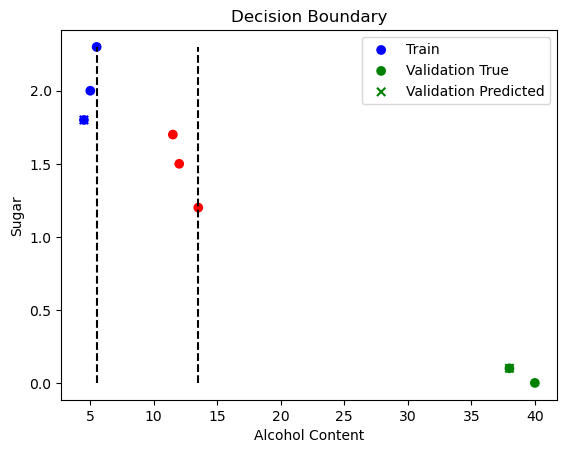

In [73]:
#Visualisation of the decision boundary in the 2D space of the first two features (Alcohol Content and Sugar)
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
plt.scatter(X_train[:,0], X_train[:,1], c=ListedColormap(['red', 'blue','green'])(Y_train), marker='o', label='Train')
plt.scatter(X_val[:,0], X_val[:,1], c=ListedColormap(['red', 'blue','green'])(Y_val), marker='o', label='Validation True')
plt.scatter(X_val[:,0], X_val[:,1], c=ListedColormap(['red', 'blue','green'])(Y_val_pred), marker='x', label='Validation Predicted')
plt.xlabel('Alcohol Content')
plt.ylabel('Sugar')
plt.title('Decision Boundary')

#plot the decision boundary of the tree by reading the thresholds from the tree and plotting them as lines.
def plot_decision_boundary(node, x_min, x_max, y_min, y_max):
    if node.is_leaf():
        return
    feature_index = node.feature_index
    threshold = node.threshold
    if feature_index == 0:  # Split on Alcohol Content
        plt.plot([threshold, threshold], [y_min, y_max], 'k--')
        plot_decision_boundary(node.left, x_min, threshold, y_min, y_max)
        plot_decision_boundary(node.right, threshold, x_max, y_min, y_max)
    elif feature_index == 1:  # Split on Sugar
        plt.plot([x_min, x_max], [threshold, threshold], 'k--')
        plot_decision_boundary(node.left, x_min, x_max, y_min, threshold)
        plot_decision_boundary(node.right, x_min, x_max, threshold, y_max)
plot_decision_boundary(solver.root, X[:,0].min(), X[:,0].max(), X[:,1].min(), X[:,1].max())


plt.legend()
plt.show()